# Лабораторна робота №3
## Наука про дані: Візуалізація даних
### Студент групи ФБ-46 Ільченко Владислав

In [1]:
# Інсталяція необхідних пакетів для візуалізації (виконується в терміналі за потреби)
# !pip install pandas numpy matplotlib seaborn requests

### Імпорт модулів та завантаження датасету
Для цієї лабораторної роботи обрано датасет **Automobile** з репозиторію UCI. 
Він містить як категоріальні, так і числові характеристики автомобілів, а також пропущені значення, позначені символом `?`.

In [2]:
import os
import urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Налаштування стилю графіків seaborn
sns.set_theme(style="whitegrid")

# URL-адреса сирих даних датасету Automobile
DATA_URL = "https://archive.ics.uci.edu/ml/machine-learning-databases/autos/imports-85.data"
FILE_PATH = "automobile.csv"

# Назви стовпців згідно зі специфікацією UCI
columns = [
    "symboling", "normalized-losses", "make", "fuel-type", "aspiration",
    "num-of-doors", "body-style", "drive-wheels", "engine-location", "wheel-base",
    "length", "width", "height", "curb-weight", "engine-type",
    "num-of-cylinders", "engine-size", "fuel-system", "bore", "stroke",
    "compression-ratio", "horsepower", "peak-rpm", "city-mpg", "highway-mpg", "price"
]

# Завантаження файлу, якщо він відсутній локально
if not os.path.exists(FILE_PATH):
    print("Завантаження датасету з UCI...")
    urllib.request.urlretrieve(DATA_URL, FILE_PATH)
    print("Завантаження завершено.")

# Зчитування даних
raw_df = pd.read_csv(FILE_PATH, names=columns, header=None)
print(f"Початковий розмір датасету: {raw_df.shape}")

Завантаження датасету з UCI...
Завантаження завершено.
Початковий розмір датасету: (205, 26)


### Етап Data Cleaning (Очищення даних)
Заміна символів `?` на валідні `NaN`, обробка пропусків та приведення числових ознак, які зчиталися як текстові через знаки питань, до типів `float`/`int`.

In [3]:
def clean_automobile_data(df):
    # 1. Заміна '?' на NaN
    df_cleaned = df.replace('?', np.nan)
    
    # 2. Визначення числових стовпців, які потребують конвертації типу
    numeric_to_convert = ['normalized-losses', 'bore', 'stroke', 'horsepower', 'peak-rpm', 'price']
    
    for col in numeric_to_convert:
        df_cleaned[col] = pd.to_numeric(df_cleaned[col], errors='coerce')
        
    # 3. Обробка Missing Values: заповнюємо пропущені значення медіаною або видаляємо критичні пропуски в ціні
    df_cleaned = df_cleaned.dropna(subset=['price', 'horsepower'])
    
    # Заповнюємо інші пропуски медіанними значеннями по відповідних стовпцях
    df_cleaned['normalized-losses'] = df_cleaned['normalized-losses'].fillna(df_cleaned['normalized-losses'].median())
    df_cleaned['bore'] = df_cleaned['bore'].fillna(df_cleaned['bore'].median())
    df_cleaned['stroke'] = df_cleaned['stroke'].fillna(df_cleaned['stroke'].median())
    df_cleaned['peak-rpm'] = df_cleaned['peak-rpm'].fillna(df_cleaned['peak-rpm'].median())
    
    return df_cleaned

df = clean_automobile_data(raw_df)
print(f"Розмір датасету після очищення: {df.shape}")
display(df.head(3))

Розмір датасету після очищення: (199, 26)


,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
0,3,115.0,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111.0,5000.0,21,27,13495.0
1,3,115.0,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111.0,5000.0,21,27,16500.0
2,1,115.0,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154.0,5000.0,19,26,16500.0


### Графік 1: Залежність одного числового атрибута від іншого (Scatter Plot)
Побудова діаграми розсіювання для відображення залежності між потужністю двигуна (`horsepower`) та ціною автомобіля (`price`).

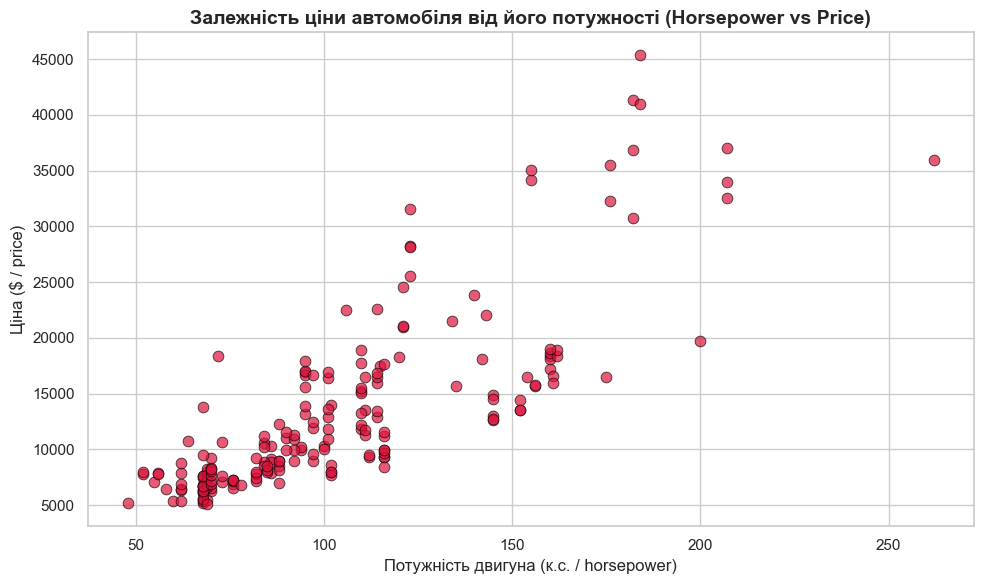

In [4]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='horsepower', y='price', color='crimson', alpha=0.7, edgecolors='black', s=60)

plt.title('Залежність ціни автомобіля від його потужності (Horsepower vs Price)', fontsize=14, fontweight='bold')
plt.xlabel('Потужність двигуна (к.с. / horsepower)', fontsize=12)
plt.ylabel('Ціна ($ / price)', fontsize=12)
plt.tight_layout()
plt.show()

### Графік 2: Гістограма по одному з атрибутів із 5 фіксованими діапазонами
Поділ значень стовпця `engine-size` (об'єм двигуна) на 5 рівномірних діапазонів користувача та побудова гістограми, що відображає кількість елементів у кожному з них.

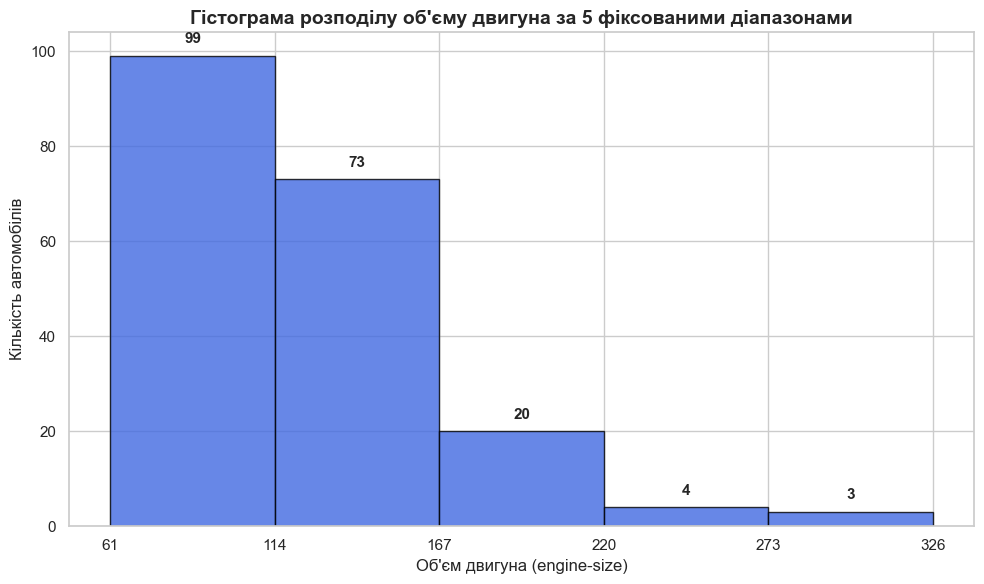

In [5]:
# Визначаємо мін і макс для побудови 5 інтервалів
min_val = df['engine-size'].min()
max_val = df['engine-size'].max()
bins = np.linspace(min_val, max_val, 6) # 6 точок дають 5 діапазонів

plt.figure(figsize=(10, 6))
# Побудова гістограми із чітко заданими межами стовпців (bins)
n, bins_edges, patches = plt.hist(df['engine-size'], bins=bins, color='royalblue', edgecolor='black', alpha=0.8)

# Додаємо підписи кількості елементів над кожним стовпчиком
for i in range(len(n)):
    plt.text(bins_edges[i] + (bins_edges[i+1] - bins_edges[i])/2, n[i] + 2, str(int(n[i])), 
             ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.title("Гістограма розподілу об'єму двигуна за 5 фіксованими діапазонами", fontsize=14, fontweight='bold')
plt.xlabel("Об'єм двигуна (engine-size)", fontsize=12)
plt.ylabel("Кількість автомобілів", fontsize=12)
plt.xticks(bins_edges) # Встановлюємо мітки на осях суворо по межах діапазонів
plt.tight_layout()
plt.show()

### Графіки 3, 4, 5: Багатовимірна візуалізація (Multi-Dimensional Data за гайдлайнами Medium статті)
Візуалізація складних зв'язків: додавання третяї та четвертої розмірностей за допомогою кольору (`hue`), розміру маркерів (`size`) та розділення на фасети (`facet grids`).

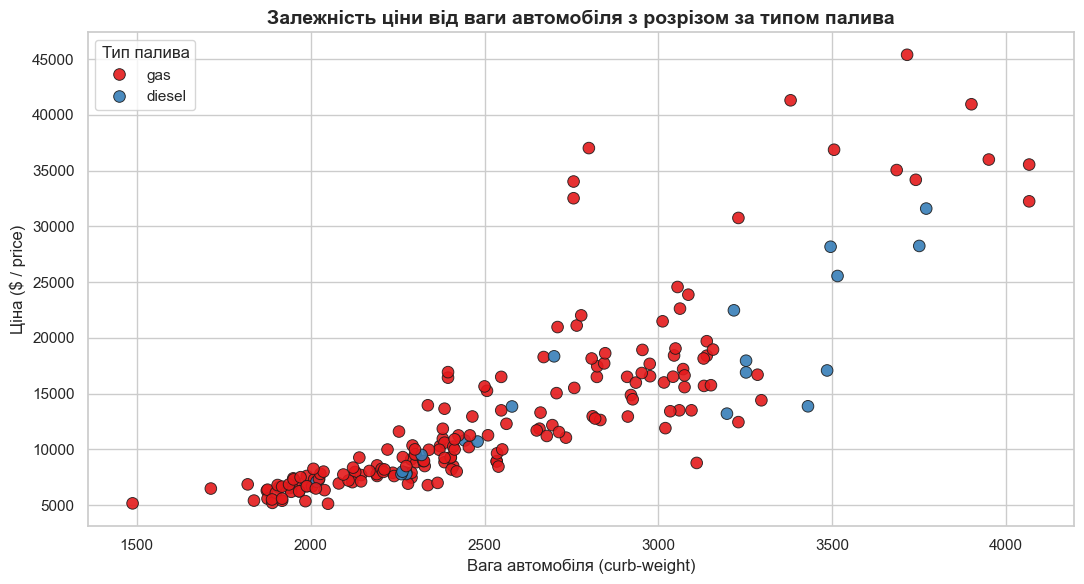

In [6]:
# Графік 3: Третя розмірність за допомогою кольору (3D аналіз на 2D площині)
plt.figure(figsize=(11, 6))
sns.scatterplot(data=df, x='curb-weight', y='price', hue='fuel-type', palette='Set1', s=70, alpha=0.9, edgecolor='k')

plt.title('Залежність ціни від ваги автомобіля з розрізом за типом палива', fontsize=14, fontweight='bold')
plt.xlabel('Вага автомобіля (curb-weight)', fontsize=12)
plt.ylabel('Ціна ($ / price)', fontsize=12)
plt.legend(title='Тип палива')
plt.tight_layout()
plt.show()

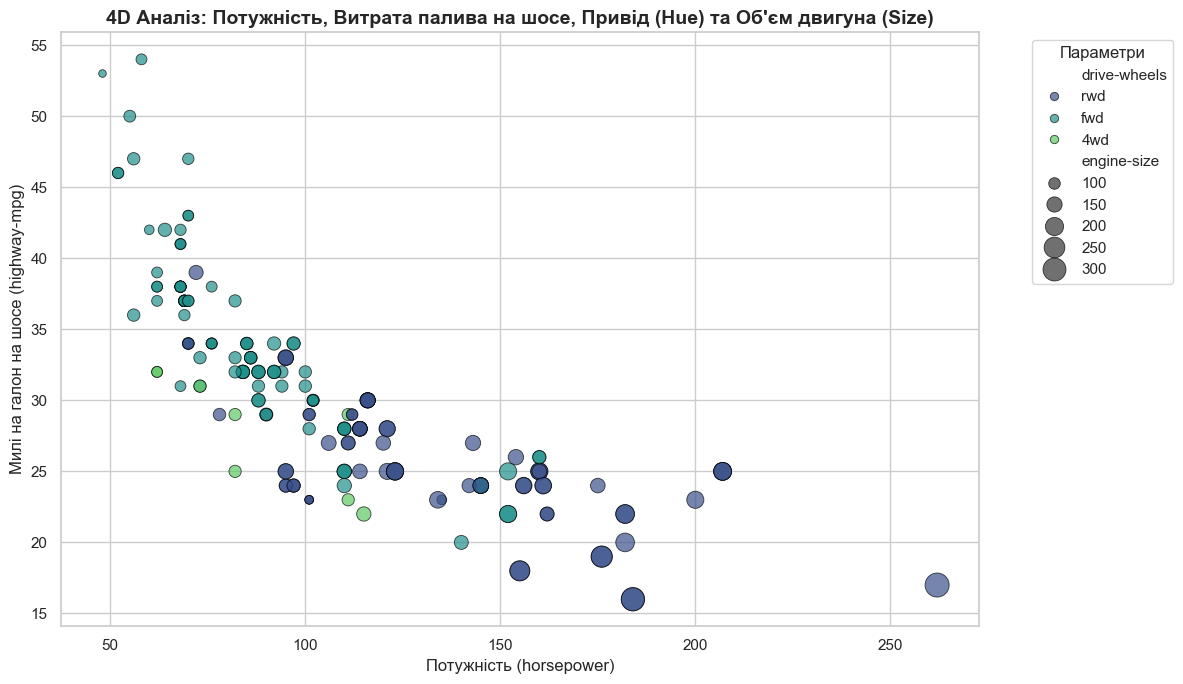

In [7]:
# Графік 4: Чотиривимірна візуалізація (Координати X, Y + Колір Hue + Розмір Size маркерів)
plt.figure(figsize=(12, 7))
sns.scatterplot(
    data=df, 
    x='horsepower', 
    y='highway-mpg', 
    hue='drive-wheels', 
    size='engine-size', 
    sizes=(30, 300), 
    palette='viridis', 
    alpha=0.7, 
    edgecolor='black'
)

plt.title('4D Аналіз: Потужність, Витрата палива на шосе, Привід (Hue) та Об\'єм двигуна (Size)', fontsize=14, fontweight='bold')
plt.xlabel('Потужність (horsepower)', fontsize=12)
plt.ylabel('Милі на галон на шосе (highway-mpg)', fontsize=12)
plt.legend(title='Параметри', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

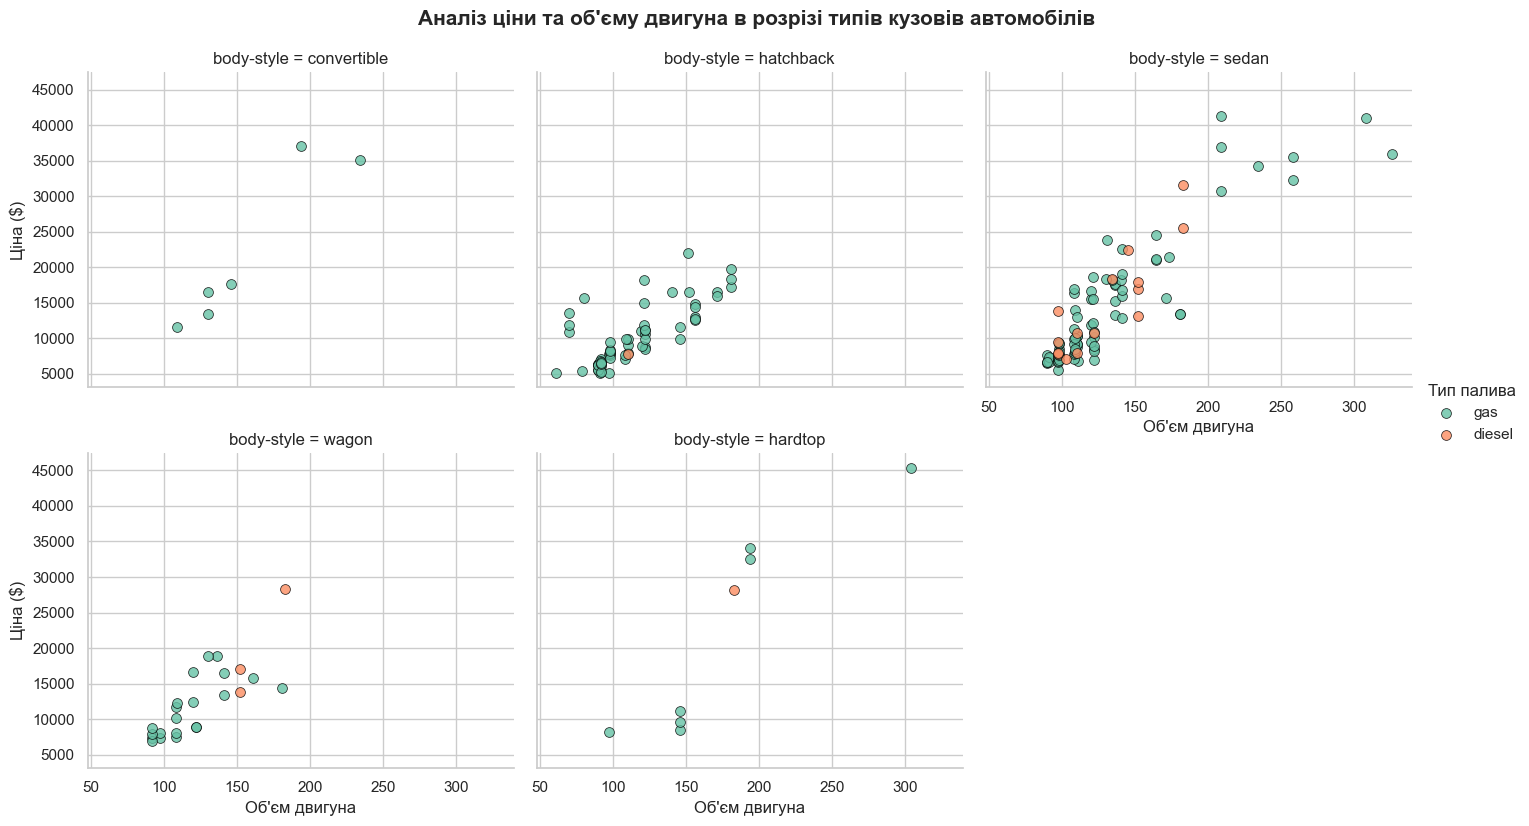

In [8]:
# Графік 5: Візуалізація через FacetGrid (Поділ на підграфіки за категоріальним атрибутом)
g = sns.FacetGrid(df, col="body-style", hue="fuel-type", palette="Set2", col_wrap=3, height=4, aspect=1.2)
g.map(sns.scatterplot, "engine-size", "price", alpha=0.8, edgecolor="black", s=50)

g.add_legend(title="Тип палива")
g.set_axis_labels("Об'єм двигуна", "Ціна ($)")
g.fig.suptitle('Аналіз ціни та об\'єму двигуна в розрізі типів кузовів автомобілів', y=1.03, fontsize=15, fontweight='bold')
plt.show()

### Графіки 6, 7, 8: Додаткові корисні графіки для аналітики датасету
Побудова матриці кореляції, діаграм розмаху (Boxplot) та парних розподілів для отримання прихованих інсайтів.

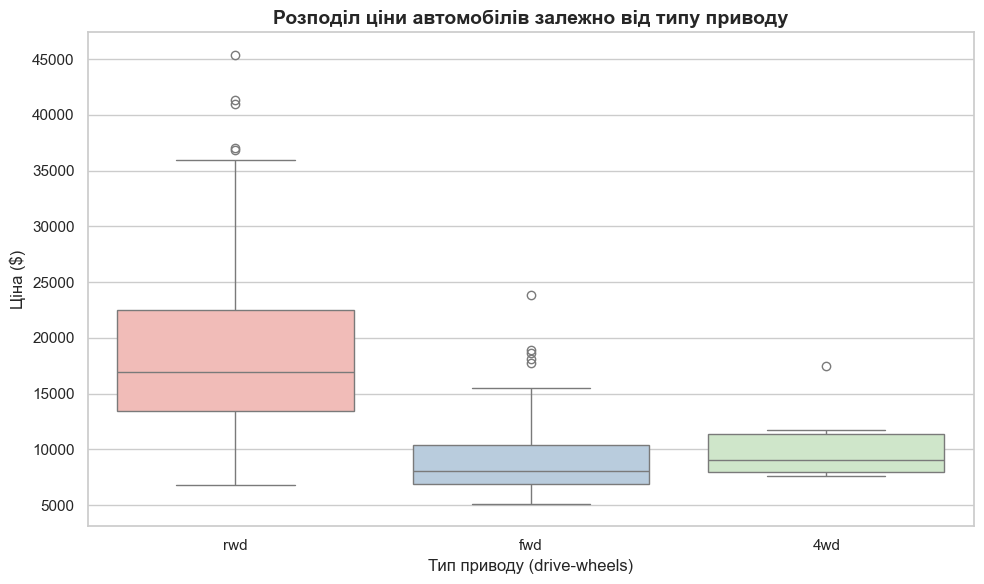

In [9]:
# Графік 6: Boxplot (Діаграма розмаху) для виявлення викидів та розподілу ціни за типами приводів
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='drive-wheels', y='price', hue='drive-wheels', palette='Pastel1', legend=False)

plt.title('Розподіл ціни автомобілів залежно від типу приводу', fontsize=14, fontweight='bold')
plt.xlabel('Тип приводу (drive-wheels)', fontsize=12)
plt.ylabel('Ціна ($)', fontsize=12)
plt.tight_layout()
plt.show()

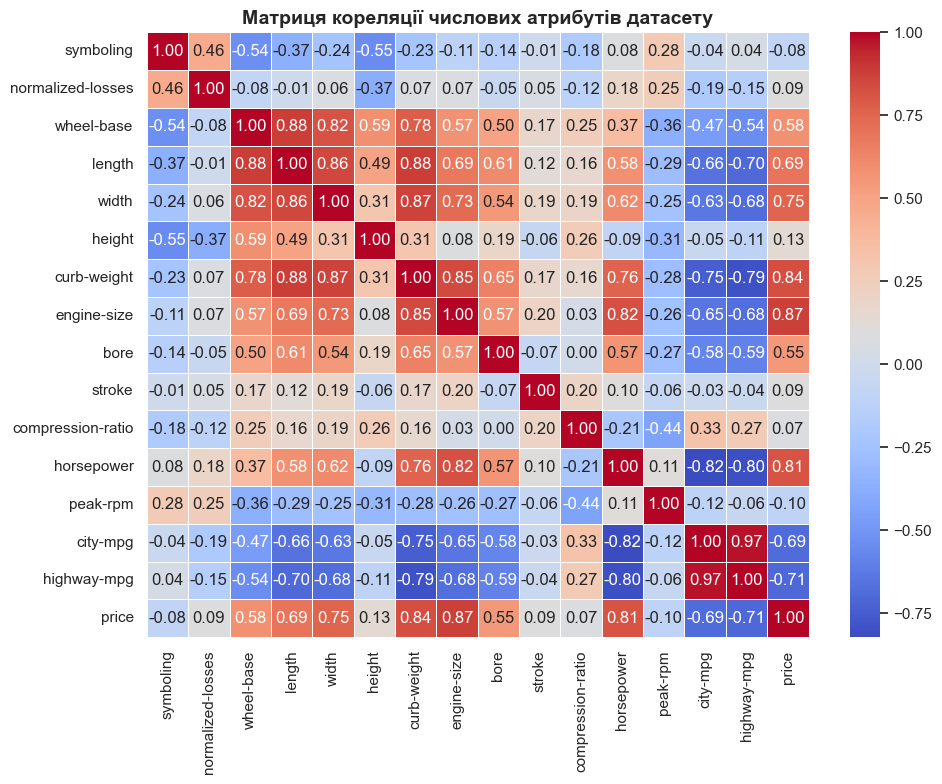

In [10]:
# Графік 7: Теплокарта (Heatmap) матриці кореляції числових ознак
plt.figure(figsize=(10, 8))
numeric_df = df.select_dtypes(include=[np.number])
corr_matrix = numeric_df.corr()

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5, cbar=True)
plt.title('Матриця кореляції числових атрибутів датасету', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

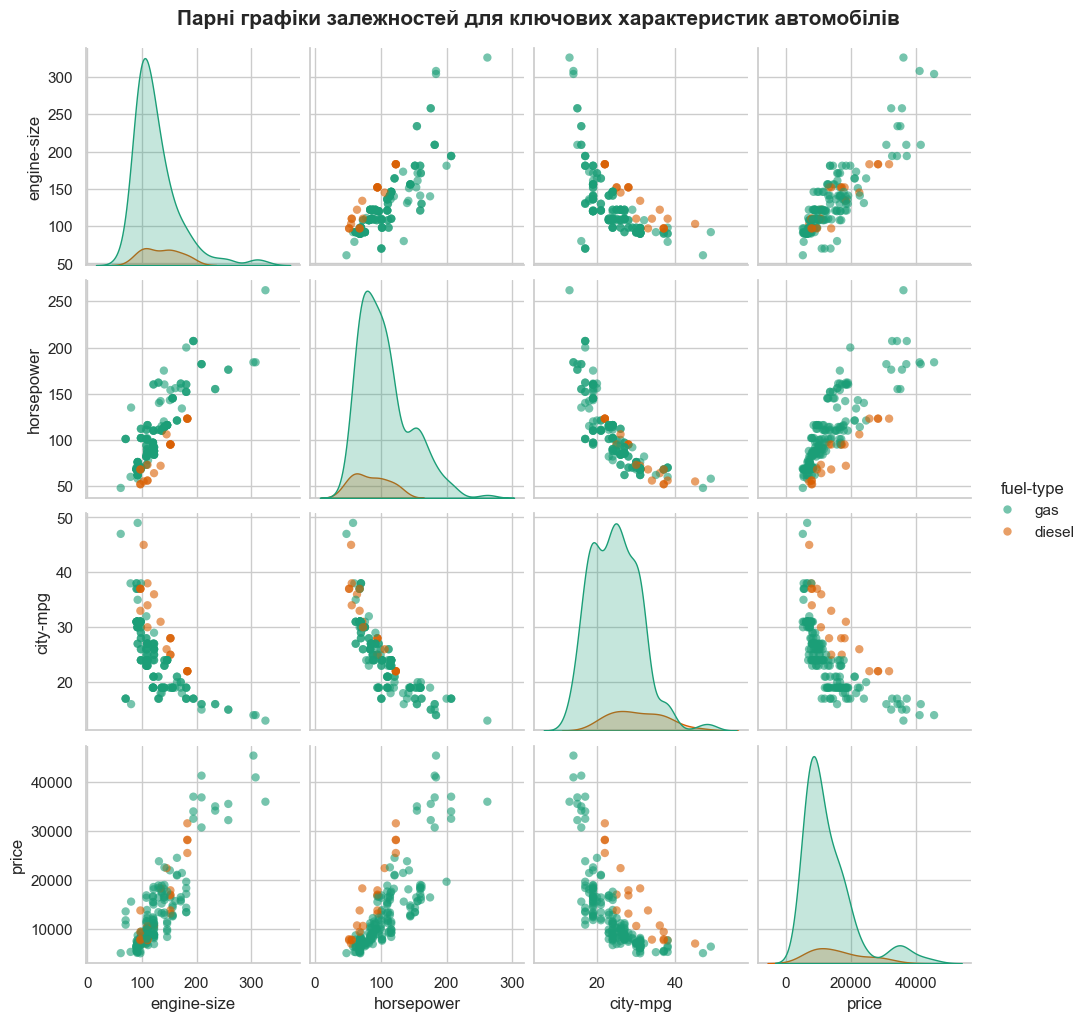

In [11]:
# Графік 8: Pairplot (Графік парних залежностей) для підмножини ключових ознак
key_features = ['engine-size', 'horsepower', 'city-mpg', 'price', 'fuel-type']
sns.pairplot(df[key_features], hue='fuel-type', palette='Dark2', diag_kind='kde', plot_kws={'alpha': 0.6, 'edgecolor': 'none'})

plt.suptitle('Парні графіки залежностей для ключових характеристик автомобілів', y=1.02, fontsize=15, fontweight='bold')
plt.show()